# Markov Chain Monte Carlo and PyMC

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain **why MCMC is necessary** — grid approximation and Laplace fail in high dimensions or for non-Normal posteriors.
2. Describe the **core idea**: construct a Markov chain whose stationary distribution is the posterior.
3. Implement the **Metropolis-Hastings algorithm** from scratch (~30 lines) and diagnose its output.
4. Explain why random-walk Metropolis is slow and how **Hamiltonian Monte Carlo** (HMC) improves it.
5. Use **PyMC** to specify Bayesian models and draw posterior samples with NUTS.
6. Compare scratch MH with PyMC's NUTS on the same problem.

## Prerequisites

- [01_bayes_theorem.ipynb](01_bayes_theorem.ipynb) — Bayes' rule, prior, likelihood, posterior
- [02_conjugate_priors.ipynb](02_conjugate_priors.ipynb) — analytical posteriors for reference
- [03_grid_and_laplace.ipynb](03_grid_and_laplace.ipynb) — grid approximation and its limitations
- [Math foundations](../00_prerequisites/02_math_foundations.ipynb) — probability, calculus

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0 pymc arviz"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# PyMC — wrapped in try/except for environments without it
try:
# PyTensor Windows fix: skip C compilation
os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="
    import pymc as pm
    import arviz as az

    HAS_PYMC = True
    print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")
except Exception:
    HAS_PYMC = False
    print("PyMC not installed — PyMC cells will be skipped.")
    print("Install with: conda install -c conda-forge pymc arviz")

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PyMC not installed — PyMC cells will be skipped.
Install with: conda install -c conda-forge pymc arviz


---

## 1. Why MCMC?

Bayesian inference requires computing the **posterior distribution**:

$$P(\theta \mid \text{data}) = \frac{P(\text{data} \mid \theta)\, P(\theta)}{P(\text{data})} = \frac{P(\text{data} \mid \theta)\, P(\theta)}{\int P(\text{data} \mid \theta)\, P(\theta)\, d\theta}$$

The denominator $P(\text{data}) = \int P(\text{data} \mid \theta)\, P(\theta)\, d\theta$ is the **marginal likelihood** (or evidence). For all but the simplest conjugate models, this integral is **intractable**.

We've seen two approximation strategies:

| Method                    | Idea                                                      | Limitation                                                                                                                                                                              |
|---------------------------|-----------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Grid approximation**    | Evaluate the posterior on a fine grid of $\theta$ values  | Computational cost grows as $G^d$ where $G$ = grid points, $d$ = number of parameters. With 100 grid points per parameter, a 10-parameter model needs $100^{10} = 10^{20}$ evaluations. |
| **Laplace approximation** | Approximate the posterior by a Normal centered at the MAP | Fails for **skewed, multimodal, or heavy-tailed** posteriors. Many realistic posteriors are not well-approximated by a Gaussian.                                                        |

### The curse of dimensionality

Most real models have many parameters. A simple hierarchical regression might have 50+ parameters. Grid approximation is completely infeasible. Laplace might miss important posterior structure. We need a method that:

1. Scales to high dimensions.
2. Works for **any** posterior shape.
3. Does **not** require evaluating the normalising constant $P(\text{data})$.

That method is **Markov Chain Monte Carlo (MCMC)**.

### Historical context

MCMC originated not in statistics but in **physics**. During the Manhattan Project (1940s), Stanislaw Ulam was recovering from brain surgery and playing solitaire. He wondered: what's the probability of winning? Rather than computing it analytically, he realised you could just **play many games and count**. He discussed this with John von Neumann, who saw the broader principle.

In 1953, Nicholas Metropolis, Arianna and Marshall Rosenbluth, and Augusta and Edward Teller published the algorithm we now call the **Metropolis algorithm**, originally for simulating the Boltzmann distribution of molecular systems. W. K. Hastings generalised it in 1970.

It took until the late 1980s for statisticians (Gelfand & Smith, 1990) to realise that MCMC could revolutionise Bayesian inference. Today, MCMC is the engine behind virtually all applied Bayesian statistics.

---

## 2. The Core Idea

The fundamental insight of MCMC is:

> **We can construct a Markov chain whose stationary distribution is the posterior.** If we run the chain long enough, the samples it produces are (dependent) samples from the posterior.

Let's unpack this:

- A **Markov chain** is a sequence of random variables $\theta^{(0)}, \theta^{(1)}, \theta^{(2)}, \dots$ where each value depends only on the previous one: $P(\theta^{(t+1)} \mid \theta^{(0)}, \dots, \theta^{(t)}) = P(\theta^{(t+1)} \mid \theta^{(t)})$.

- A **stationary distribution** $\pi(\theta)$ is one that the chain converges to regardless of where it starts. Once the chain reaches stationarity, each $\theta^{(t)} \sim \pi(\theta)$.

- The trick is to design the **transition rule** $P(\theta^{(t+1)} \mid \theta^{(t)})$ so that $\pi(\theta) = P(\theta \mid \text{data})$ — the posterior.

### What we get

After a **warmup** (or burn-in) period, the chain produces samples $\theta^{(1)}, \theta^{(2)}, \dots, \theta^{(N)}$ that are approximately from the posterior. We can then compute any posterior summary:

$$E[g(\theta) \mid \text{data}] \approx \frac{1}{N} \sum_{t=1}^{N} g(\theta^{(t)})$$

### What we give up

The samples are **not independent** — they form a Markov chain with autocorrelation. This means we need more samples than we would with independent draws, and we need to check that the chain has actually converged.

---

## 3. The Metropolis-Hastings Algorithm

The Metropolis-Hastings (MH) algorithm is the foundational MCMC method. Every modern MCMC sampler is, at its core, a clever variant of MH.

### The algorithm

Given a target distribution $P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) P(\theta)$ and a proposal distribution $q(\theta^* \mid \theta)$:

1. **Initialise** $\theta^{(0)}$ to some starting value.
2. For $t = 0, 1, 2, \dots$:
   - **Propose:** Draw $\theta^* \sim q(\theta^* \mid \theta^{(t)})$
   - **Compute acceptance ratio:**
     $$\alpha = \min\left(1, \; \frac{P(\theta^* \mid \text{data}) \cdot q(\theta^{(t)} \mid \theta^*)}{P(\theta^{(t)} \mid \text{data}) \cdot q(\theta^* \mid \theta^{(t)})}\right)$$
   - **Accept or reject:** Draw $u \sim \text{Uniform}(0, 1)$.
     - If $u < \alpha$: accept, set $\theta^{(t+1)} = \theta^*$
     - Otherwise: reject, set $\theta^{(t+1)} = \theta^{(t)}$

### Key insight: the normalising constant cancels!

Since $P(\theta \mid \text{data}) = \frac{P(\text{data} \mid \theta) P(\theta)}{Z}$, the ratio becomes:

$$\frac{P(\theta^* \mid \text{data})}{P(\theta^{(t)} \mid \text{data})} = \frac{P(\text{data} \mid \theta^*) P(\theta^*) / Z}{P(\text{data} \mid \theta^{(t)}) P(\theta^{(t)}) / Z} = \frac{P(\text{data} \mid \theta^*) P(\theta^*)}{P(\text{data} \mid \theta^{(t)}) P(\theta^{(t)})}$$

The intractable $Z$ cancels. We only need the **unnormalised** posterior.

### Symmetric proposals: the Metropolis algorithm

If the proposal distribution is **symmetric** ($q(\theta^* \mid \theta) = q(\theta \mid \theta^*)$), as for a Normal random walk, the $q$ terms also cancel:

$$\alpha = \min\left(1, \; \frac{P(\text{data} \mid \theta^*) P(\theta^*)}{P(\text{data} \mid \theta^{(t)}) P(\theta^{(t)})}\right)$$

This is the original **Metropolis algorithm** (1953). We use a Normal random walk proposal: $\theta^* \sim \mathcal{N}(\theta^{(t)}, \sigma^2_{\text{proposal}})$.

### From scratch: Metropolis for a Normal posterior

**Problem setup:** We observe data $x_1, \dots, x_n \sim \mathcal{N}(\mu, \sigma^2_{\text{known}})$ with known $\sigma^2 = 1$, and want to infer $\mu$ with a $\mathcal{N}(0, 10^2)$ prior.

The unnormalised log-posterior is:

$$\ln P(\mu \mid \text{data}) \propto \underbrace{-\frac{1}{2}\sum(x_i - \mu)^2}_{\text{log-likelihood}} + \underbrace{\left(-\frac{\mu^2}{200}\right)}_{\text{log-prior}}$$

In [2]:
# Generate observed data
true_mu = 2.5
sigma_known = 1.0
n_obs = 30
data = rng.normal(true_mu, sigma_known, size=n_obs)
print(f"Observed data: n={n_obs}, x̄={data.mean():.3f}, true μ={true_mu}")

Observed data: n=30, x̄=2.517, true μ=2.5


In [ ]:
# ── Stage 2: FROM SCRATCH — Metropolis-Hastings in ~30 lines ──


def log_posterior(mu, data, sigma=1.0, prior_mu=0.0, prior_sigma=10.0):
    """Unnormalised log-posterior for Normal mean with Normal prior."""
    log_lik = -0.5 * np.sum((data - mu) ** 2) / sigma**2
    log_prior = -0.5 * ((mu - prior_mu) / prior_sigma) ** 2
    return log_lik + log_prior


def metropolis(log_post, data, n_samples=10_000, proposal_sd=0.5, start=0.0, seed=42):
    """Metropolis algorithm with Normal random-walk proposals."""
    rng_mh = np.random.default_rng(seed)
    samples = np.empty(n_samples)
    current = start
    current_lp = log_post(current, data)
    n_accepted = 0

    for t in range(n_samples):
        # Propose
        proposed = current + rng_mh.normal(0, proposal_sd)
        proposed_lp = log_post(proposed, data)

        # Accept / reject
        log_alpha = proposed_lp - current_lp
        if np.log(rng_mh.uniform()) < log_alpha:
            current = proposed
            current_lp = proposed_lp
            n_accepted += 1

        samples[t] = current

    accept_rate = n_accepted / n_samples
    return samples, accept_rate


# Run the sampler
chain, accept_rate = metropolis(log_posterior, data, n_samples=20_000, proposal_sd=0.5)
print(f"Acceptance rate: {accept_rate:.2%}")
print(f"Posterior mean (after warmup): {chain[2000:].mean():.4f}")
print(f"Posterior std  (after warmup): {chain[2000:].std():.4f}")
print(f"Sample mean (analytical reference): {data.mean():.4f}")

Acceptance rate: 40.46%
Posterior mean (after warmup): 2.5184
Posterior std  (after warmup): 0.1826
Sample mean (analytical reference): 2.5168


That's the entire algorithm. Let's inspect what it produced.

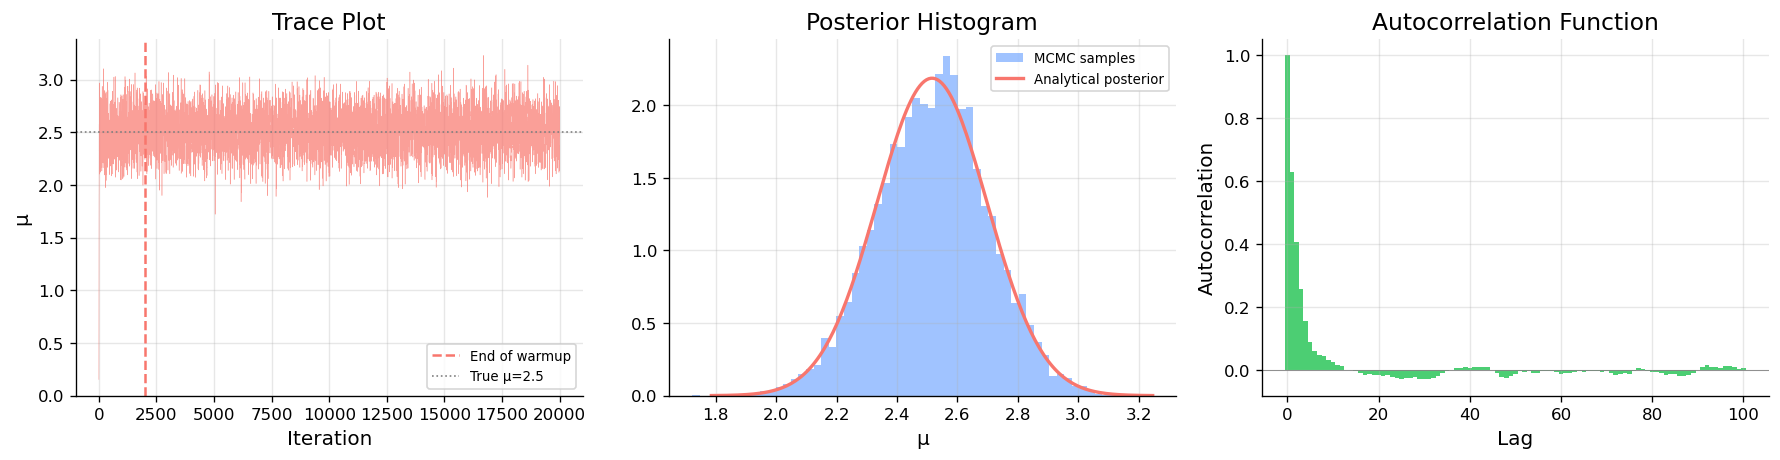


Analytical posterior: N(2.5160, 0.1825²)
MCMC estimate:       N(2.5184, 0.1826²)


In [ ]:
# Diagnostic plots: trace, histogram, autocorrelation
warmup = 2000
post_samples = chain[warmup:]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Trace plot
axes[0].plot(chain, linewidth=0.3, alpha=0.7)
axes[0].axvline(
    warmup, color="#F8766D", linestyle="--", linewidth=1.5, label="End of warmup"
)
axes[0].axhline(
    true_mu, color="grey", linestyle=":", linewidth=1, label=f"True \u03bc={true_mu}"
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("\u03bc")
axes[0].set_title("Trace Plot")
axes[0].legend(fontsize=8)

# Histogram vs analytical posterior
# Analytical posterior: Normal(posterior_mu, posterior_sigma^2)
prior_precision = 1 / 10**2
lik_precision = n_obs / sigma_known**2
post_precision = prior_precision + lik_precision
post_mu = (prior_precision * 0 + lik_precision * data.mean()) / post_precision
post_sigma = 1 / np.sqrt(post_precision)

axes[1].hist(
    post_samples,
    bins=60,
    density=True,
    alpha=0.6,
    color="#619CFF",
    label="MCMC samples",
)
mu_grid = np.linspace(post_mu - 4 * post_sigma, post_mu + 4 * post_sigma, 200)
axes[1].plot(
    mu_grid,
    stats.norm.pdf(mu_grid, post_mu, post_sigma),
    color="#F8766D",
    linewidth=2,
    label="Analytical posterior",
)
axes[1].set_xlabel("\u03bc")
axes[1].set_title("Posterior Histogram")
axes[1].legend(fontsize=8)

# Autocorrelation
max_lag = 100
acf = np.correlate(
    post_samples - post_samples.mean(), post_samples - post_samples.mean(), mode="full"
)
acf = acf[len(acf) // 2 :]
acf = acf[: max_lag + 1] / acf[0]
axes[2].bar(range(max_lag + 1), acf, width=1.0, alpha=0.7, color="#00BA38")
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("Autocorrelation")
axes[2].set_title("Autocorrelation Function")
axes[2].axhline(0, color="grey", linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\nAnalytical posterior: N({post_mu:.4f}, {post_sigma:.4f}\u00b2)")
print(
    f"MCMC estimate:       N({post_samples.mean():.4f}, {post_samples.std():.4f}\u00b2)"
)

### Reading the diagnostics

- **Trace plot:** The chain should look like a "fuzzy caterpillar" — rapidly fluctuating around the posterior mean with no trends or stuck periods. The warmup period (left of the red line) may show the chain moving from its starting value toward the high-density region.

- **Histogram:** The MCMC histogram should closely match the analytical posterior (red curve). This is our verification that the sampler is working correctly.

- **Autocorrelation:** Measures how correlated successive samples are. Ideally, autocorrelation decays quickly to zero. High autocorrelation means the chain is exploring slowly — we need many samples to get a few effectively independent ones.

### The acceptance rate

For a random-walk Metropolis in one dimension, the theoretically optimal acceptance rate is about **44%**. In higher dimensions, the optimal rate converges to about **23%** (Roberts, Gelman & Gilks, 1997). The acceptance rate is controlled by the **proposal standard deviation** $\sigma_{\text{proposal}}$:

- Too small $\sigma_{\text{proposal}}$: proposals are always close to current position $\rightarrow$ high acceptance but slow exploration.
- Too large $\sigma_{\text{proposal}}$: proposals jump far away, often into low-density regions $\rightarrow$ low acceptance, chain gets stuck.

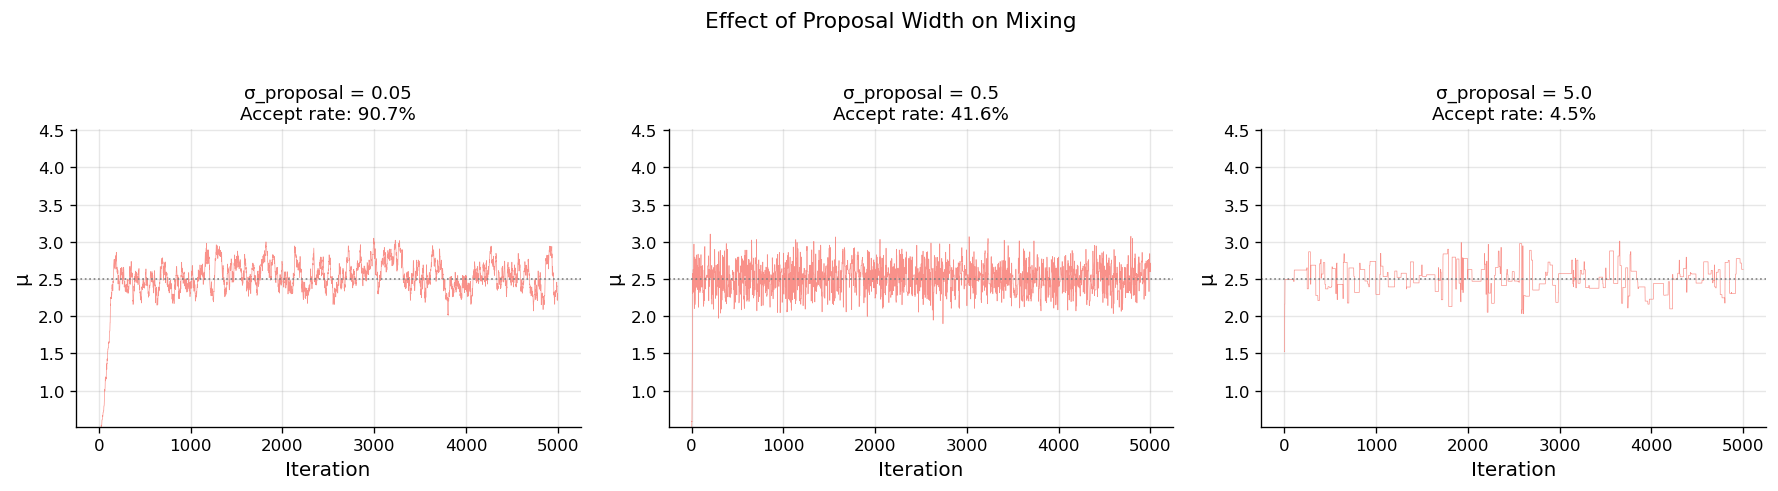

In [5]:
# Effect of proposal_sd on acceptance rate and mixing
proposal_sds = [0.05, 0.5, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, psd in zip(axes, proposal_sds):
    ch, ar = metropolis(log_posterior, data, n_samples=5000, proposal_sd=psd)
    ax.plot(ch, linewidth=0.4, alpha=0.8)
    ax.axhline(true_mu, color="grey", linestyle=":", linewidth=1)
    ax.set_title(f"\u03c3_proposal = {psd}\nAccept rate: {ar:.1%}", fontsize=11)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("\u03bc")
    ax.set_ylim(data.mean() - 2, data.mean() + 2)

plt.suptitle("Effect of Proposal Width on Mixing", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel ($\sigma = 0.05$) shows a chain that accepts nearly every proposal but moves in tiny steps — it takes a long time to explore the posterior. The right panel ($\sigma = 5.0$) shows a chain that rejects most proposals and gets stuck at the same value for long stretches. The middle panel ($\sigma = 0.5$) shows healthy mixing.

---

## 4. Animation: Metropolis Random Walk

The following Manim animation shows the Metropolis algorithm in action. A walker (gold dot) traverses a 1D posterior curve. At each step, a proposed position is shown. If accepted (green), the walker jumps; if rejected (red), it stays. Accepted positions accumulate as a histogram below, gradually converging to the posterior shape.

In [6]:
from manim import *

cfg.apply_manim_config()

from amstats.manim_utils import C

Manim Community v0.18.1

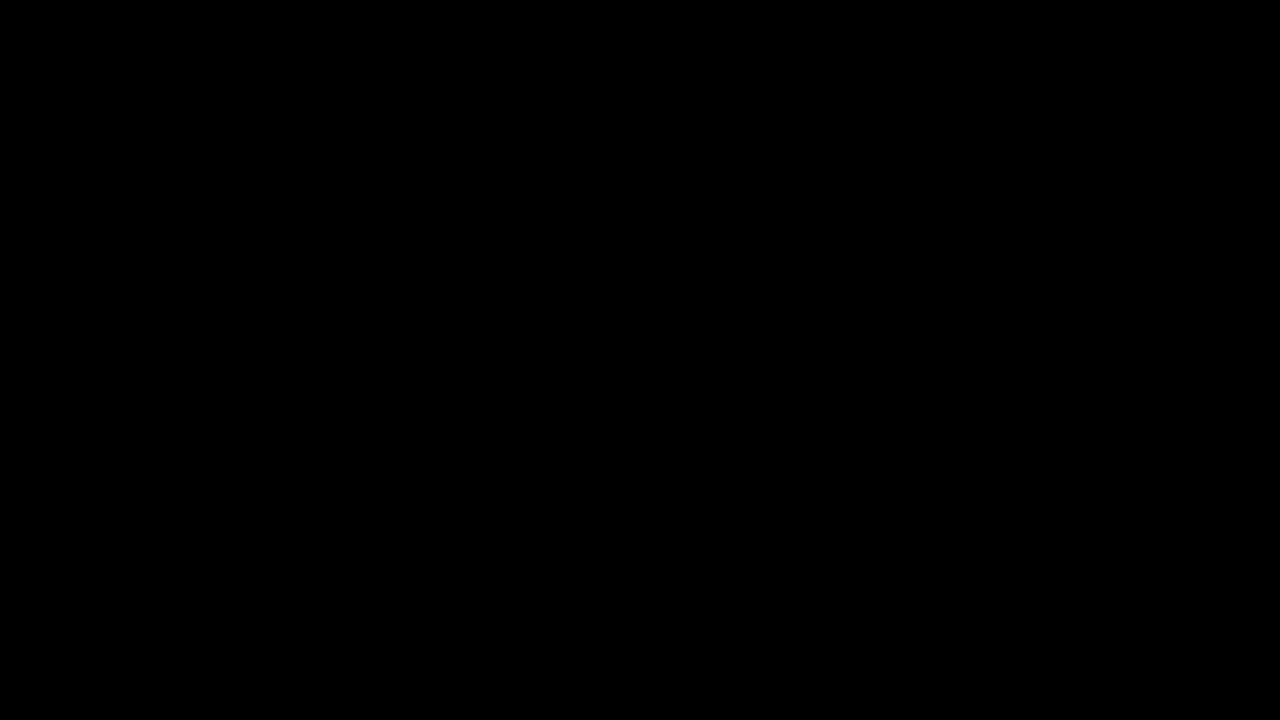

In [ ]:
%%manim -qm -v WARNING MetropolisWalk


class MetropolisWalk(Scene):
    def construct(self):
        # ── Target posterior: Normal(2.5, 0.5^2) ──
        mu_target, sigma_target = 2.5, 0.5
        x_min, x_max = 0.5, 4.5

        def posterior_pdf(x):
            return np.exp(-0.5 * ((x - mu_target) / sigma_target) ** 2) / (
                sigma_target * np.sqrt(2 * np.pi)
            )

        # ── Axes for the posterior curve (upper half) ──
        ax_post = Axes(
            x_range=[x_min, x_max, 0.5],
            y_range=[0, 1.0, 0.2],
            x_length=10,
            y_length=2.8,
            axis_config={"include_numbers": True, "font_size": 20},
        ).shift(UP * 1.2)

        post_curve = ax_post.plot(
            posterior_pdf,
            x_range=[x_min, x_max, 0.01],
            color=C.PERIWINKLE,
            stroke_width=3,
        )
        post_label = Text("Target posterior", font_size=20, color=C.PERIWINKLE).next_to(
            ax_post, UP, buff=0.15
        )

        # ── Axes for the histogram (lower half) ──
        ax_hist = Axes(
            x_range=[x_min, x_max, 0.5],
            y_range=[0, 1.0, 0.2],
            x_length=10,
            y_length=2.0,
            axis_config={"include_numbers": True, "font_size": 20},
        ).shift(DOWN * 2.0)

        hist_label = Text("Accumulated samples", font_size=20, color=C.LABEL).next_to(
            ax_hist, UP, buff=0.1
        )

        self.play(Create(ax_post), Create(post_curve), FadeIn(post_label), run_time=1)
        self.play(Create(ax_hist), FadeIn(hist_label), run_time=0.7)

        # ── Metropolis walk ──
        rng_anim = np.random.default_rng(17)
        current_x = 1.0  # start far from mode
        proposal_sd = 0.4
        n_steps = 60

        # Walker dot on the posterior curve
        walker = Dot(
            ax_post.c2p(current_x, posterior_pdf(current_x)),
            color=C.GOLD,
            radius=0.1,
            z_index=5,
        )
        self.play(FadeIn(walker), run_time=0.4)

        # Histogram bins
        n_bins = 25
        bin_edges = np.linspace(x_min, x_max, n_bins + 1)
        bin_counts = np.zeros(n_bins)
        bin_width = (x_max - x_min) / n_bins
        hist_bars = VGroup()

        # Counters
        accept_count = 0
        counter_text = Text(
            f"Step 0 | Accepted: 0", font_size=18, color=C.LABEL
        ).to_corner(UR, buff=0.3)
        self.play(FadeIn(counter_text), run_time=0.3)

        accepted_samples = []

        for step in range(n_steps):
            proposed_x = current_x + rng_anim.normal(0, proposal_sd)
            proposed_x = np.clip(proposed_x, x_min + 0.01, x_max - 0.01)

            # Show proposal as ghost dot
            ghost = Dot(
                ax_post.c2p(proposed_x, posterior_pdf(proposed_x)),
                color=C.NEUTRAL,
                radius=0.08,
                fill_opacity=0.5,
            )
            self.play(FadeIn(ghost), run_time=0.08)

            # Acceptance
            log_alpha = np.log(posterior_pdf(proposed_x) + 1e-30) - np.log(
                posterior_pdf(current_x) + 1e-30
            )
            accept = np.log(rng_anim.uniform()) < log_alpha

            if accept:
                accept_count += 1
                # Flash green, move walker
                ghost.set_color(C.EMERALD)
                self.play(
                    walker.animate.move_to(
                        ax_post.c2p(proposed_x, posterior_pdf(proposed_x))
                    ),
                    ghost.animate.set_opacity(0),
                    run_time=0.1,
                )
                current_x = proposed_x
            else:
                # Flash red, stay
                ghost.set_color(C.SALMON)
                self.play(ghost.animate.set_opacity(0), run_time=0.1)

            self.remove(ghost)
            accepted_samples.append(current_x)

            # Update histogram
            bin_idx = min(int((current_x - x_min) / bin_width), n_bins - 1)
            bin_counts[bin_idx] += 1

            # Redraw histogram bars
            max_count = max(bin_counts.max(), 1)
            new_bars = VGroup()
            for i in range(n_bins):
                if bin_counts[i] > 0:
                    bar_height = bin_counts[i] / max_count * 0.9
                    left = ax_hist.c2p(bin_edges[i], 0)
                    right = ax_hist.c2p(bin_edges[i + 1], bar_height)
                    bar = Rectangle(
                        width=abs(right[0] - left[0]),
                        height=abs(right[1] - left[1]),
                        fill_color=C.PERIWINKLE,
                        fill_opacity=0.5,
                        stroke_width=0.5,
                    ).move_to([(left[0] + right[0]) / 2, (left[1] + right[1]) / 2, 0])
                    new_bars.add(bar)

            self.remove(hist_bars)
            hist_bars = new_bars
            self.add(hist_bars)

            # Update counter
            new_counter = Text(
                f"Step {step + 1} | Accepted: {accept_count}",
                font_size=18,
                color=C.LABEL,
            ).to_corner(UR, buff=0.3)
            self.remove(counter_text)
            counter_text = new_counter
            self.add(counter_text)

        self.wait(1.5)

Watch how the walker initially moves toward the peak of the posterior and then oscillates around it. Rejected proposals (red flashes) occur more often when the walker tries to move into low-density regions. Over time, the histogram below fills in to match the shape of the posterior curve.

---

## 5. Why Metropolis Is Slow — Motivation for HMC

The random-walk Metropolis algorithm has a fundamental problem: **it explores the posterior by diffusion**. Each step is a small random perturbation of the current position. This leads to:

1. **High autocorrelation:** Successive samples are very similar, so we need many draws to get a few effectively independent ones.

2. **Poor scaling with dimension:** In $d$ dimensions, the optimal proposal size shrinks as $O(d^{-1/2})$, and the number of steps needed to traverse the posterior grows as $O(d)$. A 100-dimensional posterior might need millions of iterations.

3. **Difficulty with correlations:** If parameters are correlated in the posterior, the random walk wastes many proposals moving in "wrong" directions.

To illustrate, let's compute the **effective sample size (ESS)** — the number of independent samples equivalent to our correlated chain:

In [ ]:
# Effective sample size (simple estimator)
def ess_simple(chain):
    """Estimate ESS using initial positive sequence estimator."""
    n = len(chain)
    mean = chain.mean()
    var = chain.var()
    if var == 0:
        return 0
    # Compute autocorrelation and sum until it goes negative
    acf_sum = 0
    for lag in range(1, n):
        c = np.mean((chain[:-lag] - mean) * (chain[lag:] - mean)) / var
        if c < 0:
            break
        acf_sum += c
    return n / (1 + 2 * acf_sum)


ess = ess_simple(post_samples)
print(f"Chain length (post-warmup): {len(post_samples):,}")
print(f"Effective sample size:      {ess:.0f}")
print(f"Efficiency:                 {ess / len(post_samples):.1%}")

Chain length (post-warmup): 18,000
Effective sample size:      3923
Efficiency:                 21.8%


Even in this simple 1D problem, we're only getting a fraction of our samples as effectively independent draws. In high dimensions, the situation is dramatically worse.

---

## 6. Hamiltonian Monte Carlo — Intuition

**Hamiltonian Monte Carlo (HMC)** solves the inefficiency of random-walk Metropolis by using the **gradient** of the log-posterior to make intelligent proposals.

### The physics analogy

Imagine placing a frictionless ball on a surface shaped like the **negative log-posterior** $U(\theta) = -\ln P(\theta \mid \text{data})$. The posterior modes correspond to **valleys** in this surface.

1. Give the ball a random "kick" (sample a momentum $p \sim \mathcal{N}(0, M)$).
2. Let the ball roll according to **Hamilton's equations** for some time:
   $$\frac{d\theta}{dt} = \frac{p}{M}, \qquad \frac{dp}{dt} = -\nabla U(\theta)$$
3. The ball naturally moves toward high-density regions (valleys) and away from low-density regions (hills).
4. The final position of the ball is a **proposal** — accept or reject with a Metropolis step.

### Why is this better?

- The gradient $\nabla U(\theta) = -\nabla \ln P(\theta \mid \text{data})$ tells the ball which direction is "uphill" in posterior density. Instead of random diffusion, the sampler is **guided** toward high-probability regions.
- HMC can make large moves across the posterior while maintaining a high acceptance rate.
- Autocorrelation is much lower than random-walk Metropolis.

### NUTS: No-U-Turn Sampler

HMC has two tuning parameters: the **step size** $\epsilon$ and the **number of leapfrog steps** $L$. Setting these by hand is tedious and problem-specific.

The **No-U-Turn Sampler** (NUTS; Hoffman & Gelman, 2014) automatically adapts both parameters during warmup. It runs the Hamiltonian trajectory until the ball starts to "turn around" (make a U-turn), then stops.

**NUTS is what PyMC and Stan use by default.** You almost never need to tune the sampler by hand.

---

## 7. PyMC: The Professional Tool

PyMC is a probabilistic programming library that lets you specify Bayesian models in Python and draw posterior samples using state-of-the-art MCMC (NUTS). It handles:

- Automatic gradient computation (via PyTensor/Aesara)
- Adaptive tuning of NUTS parameters
- Multiple chains for convergence diagnostics
- Integration with ArviZ for visualisation and summary

### Basic syntax

```python
import pymc as pm

with pm.Model() as model:
    # Priors
    mu = pm.Normal("mu", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=5)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data)

    # Sample
    trace = pm.sample(2000, tune=1000, random_seed=42)
```

### Example 1: Coin bias estimation with Beta prior

We observe 14 heads in 20 flips and want to estimate the bias $\theta$ with a $\text{Beta}(2, 2)$ prior.

The conjugate posterior is $\text{Beta}(2 + 14, 2 + 6) = \text{Beta}(16, 8)$, so we can check PyMC's output against the exact answer.

In [ ]:
# Coin flip data
n_flips = 20
n_heads = 14

if HAS_PYMC:
    with pm.Model() as coin_model:
        # Prior
        theta = pm.Beta("theta", alpha=2, beta=2)

        # Likelihood
        y = pm.Binomial("y", n=n_flips, p=theta, observed=n_heads)

        # Sample with NUTS
        coin_trace = pm.sample(2000, tune=1000, chains=4, random_seed=42)

    print(az.summary(coin_trace, var_names=["theta"]))
else:
    print("PyMC not available — skipping. See analytical result below.")

# Analytical reference
a_post, b_post = 2 + n_heads, 2 + (n_flips - n_heads)
print(f"\nAnalytical posterior: Beta({a_post}, {b_post})")
print(f"  Mean: {a_post / (a_post + b_post):.4f}")
print(
    f"  Std:  {np.sqrt(a_post * b_post / ((a_post + b_post) ** 2 * (a_post + b_post + 1))):.4f}"
)

PyMC not available — skipping. See analytical result below.

Analytical posterior: Beta(16, 8)
  Mean: 0.6667
  Std:  0.0943


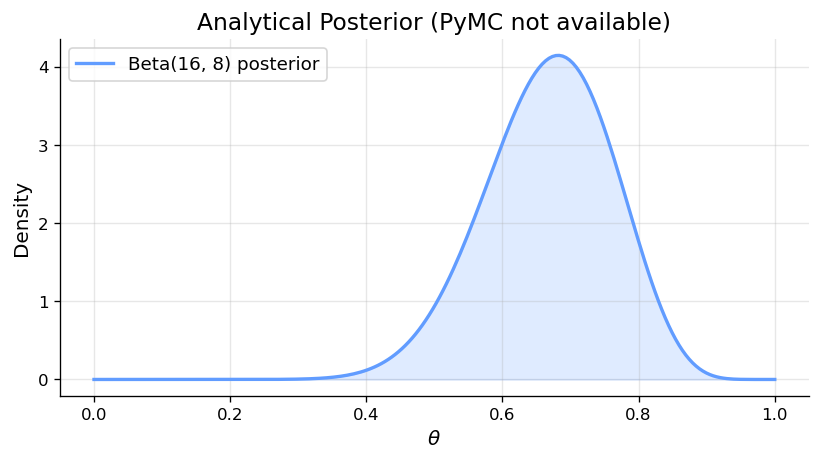

In [ ]:
if HAS_PYMC:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Trace plot
    az.plot_trace(coin_trace, var_names=["theta"], ax=axes.reshape(1, 2))
    plt.tight_layout()
    plt.show()
else:
    # Fallback: show analytical posterior
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.linspace(0, 1, 200)
    ax.plot(
        x,
        stats.beta.pdf(x, a_post, b_post),
        linewidth=2,
        color="#619CFF",
        label=f"Beta({a_post}, {b_post}) posterior",
    )
    ax.fill_between(x, stats.beta.pdf(x, a_post, b_post), alpha=0.2, color="#619CFF")
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("Density")
    ax.set_title("Analytical Posterior (PyMC not available)")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Example 2: Normal model with unknown $\mu$ and $\sigma$

Now a more realistic problem with **two parameters**. We observe data and want to infer both the mean and standard deviation.

**Priors:**
- $\mu \sim \mathcal{N}(0, 10^2)$
- $\sigma \sim \text{HalfNormal}(5)$ (constrained to be positive)

In [11]:
# Use the same data as before (Normal with true_mu=2.5, sigma=1)

if HAS_PYMC:
    with pm.Model() as normal_model:
        # Priors
        mu = pm.Normal("mu", mu=0, sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=5)

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data)

        # Sample
        normal_trace = pm.sample(2000, tune=1000, chains=4, random_seed=42)

    print(az.summary(normal_trace, var_names=["mu", "sigma"]))
    print(f"\nTrue values: mu={true_mu}, sigma={sigma_known}")
else:
    print("PyMC not available — skipping.")
    print(f"True values: mu={true_mu}, sigma={sigma_known}")
    print(f"Sample mean: {data.mean():.4f}, sample std: {data.std(ddof=1):.4f}")

PyMC not available — skipping.
True values: mu=2.5, sigma=1.0
Sample mean: 2.5168, sample std: 0.7767


In [ ]:
if HAS_PYMC:
    # ArviZ posterior plots
    az.plot_posterior(
        normal_trace,
        var_names=["mu", "sigma"],
        ref_val={"mu": true_mu, "sigma": sigma_known},
    )
    plt.suptitle("Posterior Distributions (PyMC NUTS)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("PyMC not available — skipping posterior plots.")

PyMC not available — skipping posterior plots.


### Accessing the trace

PyMC returns an `InferenceData` object (from ArviZ). Key attributes:

- `trace.posterior` — xarray Dataset with posterior samples, shape `(chains, draws, ...)`
- `trace.posterior["mu"]` — samples for a specific parameter
- `az.summary(trace)` — summary table with mean, sd, HDI, ESS, R-hat
- `az.plot_trace(trace)` — trace plots + posterior KDE
- `az.plot_posterior(trace)` — posterior histograms with HDI
- `az.plot_pair(trace)` — pairwise scatter/contour of parameters

In [ ]:
if HAS_PYMC:
    # Accessing raw samples
    mu_samples = normal_trace.posterior["mu"].values.flatten()
    sigma_samples = normal_trace.posterior["sigma"].values.flatten()

    print(f"Number of posterior samples: {len(mu_samples):,}")
    print(f"\nmu:    mean={mu_samples.mean():.4f}, std={mu_samples.std():.4f}")
    print(f"sigma: mean={sigma_samples.mean():.4f}, std={sigma_samples.std():.4f}")

    # 94% HDI (Highest Density Interval)
    print(f"\n94% HDI for mu:    {az.hdi(normal_trace, var_names=['mu'])['mu'].values}")
    print(
        f"94% HDI for sigma: {az.hdi(normal_trace, var_names=['sigma'])['sigma'].values}"
    )
else:
    print("PyMC not available — skipping.")

PyMC not available — skipping.


---

## 8. Comparison: Scratch MH vs. PyMC's NUTS

Let's solve the same Normal-mean problem with both approaches and compare quality and speed.

In [ ]:
import time

# ── Scratch Metropolis ──
t0 = time.perf_counter()
mh_chain, mh_accept = metropolis(log_posterior, data, n_samples=20_000, proposal_sd=0.5)
mh_time = time.perf_counter() - t0
mh_samples = mh_chain[2000:]  # discard warmup
mh_ess = ess_simple(mh_samples)

print("=== Scratch Metropolis-Hastings ===")
print(f"  Time:            {mh_time:.3f} s")
print(f"  Samples (post-warmup): {len(mh_samples):,}")
print(f"  ESS:             {mh_ess:.0f}")
print(f"  ESS/s:           {mh_ess / mh_time:.0f}")
print(f"  Acceptance rate: {mh_accept:.1%}")
print(f"  Mean:  {mh_samples.mean():.4f}")
print(f"  Std:   {mh_samples.std():.4f}")

# ── PyMC NUTS ──
if HAS_PYMC:
    t0 = time.perf_counter()
    with pm.Model() as compare_model:
        mu_c = pm.Normal("mu", mu=0, sigma=10)
        y_c = pm.Normal("y", mu=mu_c, sigma=sigma_known, observed=data)
        compare_trace = pm.sample(
            2000, tune=1000, chains=4, random_seed=42, progressbar=False
        )
    pymc_time = time.perf_counter() - t0
    pymc_mu = compare_trace.posterior["mu"].values.flatten()
    summary = az.summary(compare_trace, var_names=["mu"])
    pymc_ess = summary["ess_bulk"].values[0]

    print("\n=== PyMC NUTS ===")
    print(f"  Time:            {pymc_time:.3f} s")
    print(f"  Samples:         {len(pymc_mu):,} (4 chains x 2000)")
    print(f"  ESS (bulk):      {pymc_ess:.0f}")
    print(f"  ESS/s:           {pymc_ess / pymc_time:.0f}")
    print(f"  Mean:  {pymc_mu.mean():.4f}")
    print(f"  Std:   {pymc_mu.std():.4f}")
    print(f"  R-hat: {summary['r_hat'].values[0]:.4f}")
else:
    print("\nPyMC not available — skipping NUTS comparison.")

=== Scratch Metropolis-Hastings ===
  Time:            0.187 s
  Samples (post-warmup): 18,000
  ESS:             3923
  ESS/s:           20999
  Acceptance rate: 40.5%
  Mean:  2.5184
  Std:   0.1826

PyMC not available — skipping NUTS comparison.


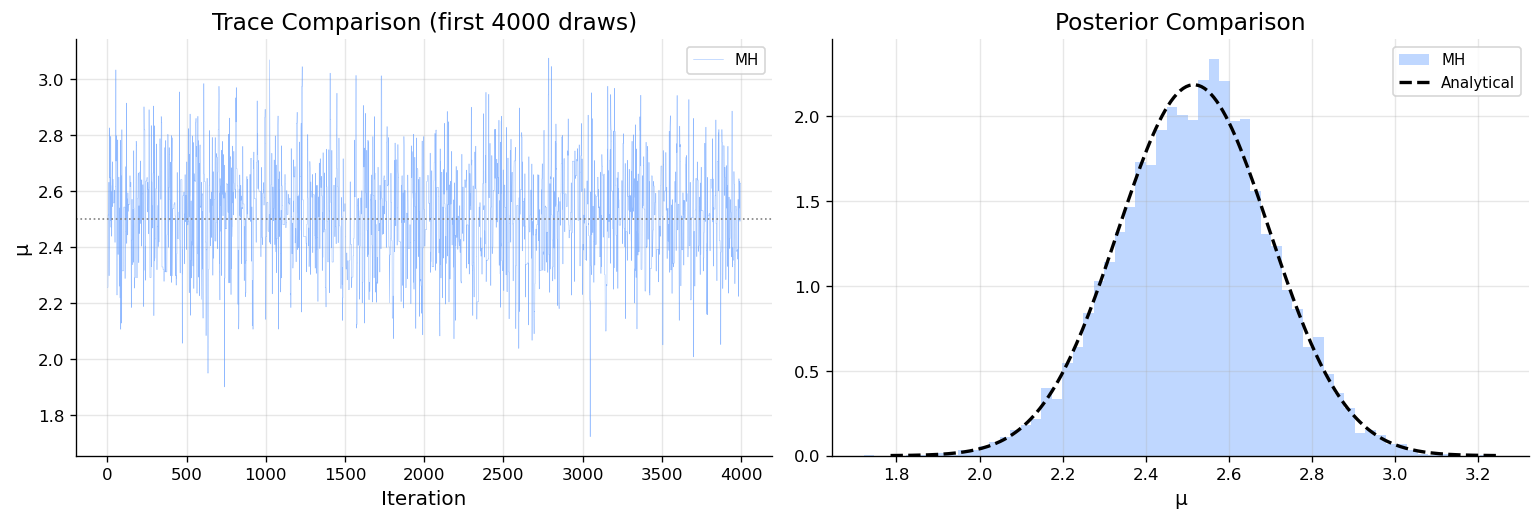

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Trace plots
axes[0].plot(mh_samples[:4000], linewidth=0.3, alpha=0.7, color="#619CFF", label="MH")
if HAS_PYMC:
    nuts_samples = compare_trace.posterior["mu"].values[0, :]  # chain 0
    axes[0].plot(
        nuts_samples[:4000], linewidth=0.3, alpha=0.7, color="#F8766D", label="NUTS"
    )
axes[0].axhline(true_mu, color="grey", linestyle=":", linewidth=1)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("\u03bc")
axes[0].set_title("Trace Comparison (first 4000 draws)")
axes[0].legend(fontsize=9)

# Posterior histograms
axes[1].hist(mh_samples, bins=60, density=True, alpha=0.4, color="#619CFF", label="MH")
if HAS_PYMC:
    axes[1].hist(
        pymc_mu, bins=60, density=True, alpha=0.4, color="#F8766D", label="NUTS"
    )
# Analytical
mu_grid = np.linspace(post_mu - 4 * post_sigma, post_mu + 4 * post_sigma, 200)
axes[1].plot(
    mu_grid,
    stats.norm.pdf(mu_grid, post_mu, post_sigma),
    color="black",
    linewidth=2,
    linestyle="--",
    label="Analytical",
)
axes[1].set_xlabel("\u03bc")
axes[1].set_title("Posterior Comparison")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Both methods recover the correct posterior, but NUTS is dramatically more efficient:

- **Lower autocorrelation:** The NUTS trace looks "hairier" — it moves around the posterior more rapidly.
- **Higher ESS per second:** NUTS produces more effective samples per unit of computation time.
- **Multiple chains:** Running 4 chains enables convergence diagnostics (R-hat) that are impossible with a single chain.

For this simple 1D problem the difference is modest, but in realistic high-dimensional models, NUTS can be **orders of magnitude** more efficient than random-walk Metropolis.

---

## Exercises

**Exercise 4.1 (Metropolis tuning).** Run the scratch `metropolis` function with `proposal_sd` values of 0.01, 0.1, 0.5, 1.0, 5.0, and 10.0 on the same Normal-mean problem. For each, record the acceptance rate and compute the ESS. Plot acceptance rate vs. ESS. What proposal width gives the best ESS?

**Exercise 4.2 (Two-parameter Metropolis).** Extend the scratch Metropolis to jointly sample $\mu$ and $\sigma$ for the Normal model. Use a 2D Normal random walk proposal. Compare the trace plots with PyMC's output. (*Hint:* sample $\log\sigma$ to avoid boundary issues.)

**Exercise 4.3 (Poisson model in PyMC).** You observe counts $y = [3, 7, 5, 8, 4, 6, 2, 9, 5, 4]$ from a Poisson distribution. Use PyMC to estimate $\lambda$ with a $\text{Gamma}(2, 1)$ prior. Report the posterior mean, 94% HDI, and compare with the conjugate analytical result.

**Exercise 4.4 (Burn-in investigation).** Run the scratch Metropolis starting from $\mu_0 = -10$ (far from the posterior mode). How many iterations does it take for the chain to reach the high-density region? Experiment with different starting values and document what you observe.

**Exercise 4.5 (Challenge — bimodal target).** Define a target distribution that is a mixture of two Normals: $p(\theta) = 0.4 \cdot \mathcal{N}(-2, 0.5^2) + 0.6 \cdot \mathcal{N}(3, 0.8^2)$. Run scratch Metropolis with different proposal widths. Can the chain reliably visit both modes? How many samples are needed? Discuss why multimodal posteriors are particularly challenging for MCMC.

---

## Key Takeaways

1. **MCMC draws samples from the posterior** without evaluating the normalising constant — it only needs the unnormalised posterior $P(\text{data} \mid \theta) P(\theta)$.

2. **Metropolis-Hastings** is the foundational MCMC algorithm: propose, compute acceptance ratio, accept or reject. The normalising constant cancels in the ratio.

3. **Random-walk Metropolis** uses a symmetric Normal proposal and simplifies the acceptance ratio. The proposal width controls the acceptance rate; ~23% is optimal in high dimensions.

4. **Metropolis is slow** because it explores by diffusion. Autocorrelation is high and efficiency drops in high dimensions.

5. **HMC/NUTS** uses gradients to make smart proposals, dramatically improving efficiency. This is what PyMC and Stan use by default.

6. **PyMC** is the professional tool: specify priors and likelihood, call `pm.sample()`, and use ArviZ for diagnostics and summaries.

7. Always check **convergence diagnostics**: trace plots, R-hat, and ESS (covered in depth in the next notebook).

**Next:** [05_mcmc_diagnostics.ipynb](05_mcmc_diagnostics.ipynb) — How to diagnose convergence, interpret R-hat, ESS, and divergences.

In [16]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BayesianUpdating@2026-03-19@21-38-46.gif
  ✓ media/gifs/MetropolisWalk@2026-03-19@21-55-53.gif
  ✓ media/gifs/PriorSensitivity@2026-03-19@21-46-08.gif
  ✓ media/gifs/MetropolisWalk_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
